# Exploración de la Base de Datos ECG con Artefactos de Movimiento
**Motion Artifact Contaminated ECG Database v1.0.0**

Este notebook explora la base de datos de señales ECG contaminadas con artefactos de movimiento. La base contiene 27 registros de múltiples sujetos con diferentes actividades físicas y ángulos de colocación del electrodo.

In [1]:
import os
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.join("..", "data", "motion-artifact-contaminated-ecg-database-1.0.0")
CHANNELS = ["ECG1", "ECG2", "ECG3", "ECG4"]

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Lista de registros disponibles

In [2]:
records_path = os.path.join(DATA_DIR, "RECORDS")
with open(records_path) as f:
    records = [l.strip() for l in f if l.strip()]

print(f"Total de registros: {len(records)}")
print(records)

Total de registros: 27
['test01_00s', 'test02_45s', 'test03_90s', 'test04_00s', 'test05_45s', 'test06_90s', 'test07_00s', 'test08_45s', 'test09_90s', 'test10_00w', 'test11_45w', 'test12_90w', 'test13_00w', 'test14_45w', 'test15_90w', 'test16_00w', 'test17_45w', 'test18_90w', 'test19_00j', 'test20_45j', 'test21_90j', 'test22_00j', 'test23_45j', 'test24_90j', 'test25_00j', 'test26_45j', 'test27_90j']


## 2. Cargar y explorar un registro

In [3]:
# Leer el primer registro
rec = wfdb.rdrecord(os.path.join(DATA_DIR, records[0]))

print(f"Nombre        : {rec.record_name}")
print(f"Canales       : {rec.sig_name}")
print(f"Frecuencia    : {rec.fs} Hz")
print(f"Muestras      : {rec.sig_len}")
print(f"Duración      : {rec.sig_len / rec.fs:.1f} s")
print(f"Unidades      : {rec.units}")

Nombre        : test01_00s
Canales       : ['ECG 1', 'ECG 2', 'ECG 3', 'ECG 4']
Frecuencia    : 500 Hz
Muestras      : 4000
Duración      : 8.0 s
Unidades      : ['mV', 'mV', 'mV', 'mV']


## 3. Convertir a DataFrame con pandas

In [4]:
fs = rec.fs
time_s = np.arange(rec.sig_len) / fs
df = pd.DataFrame(rec.p_signal, columns=CHANNELS)
df.insert(0, "time_s", time_s)

print(df.shape)
df.head()

(4000, 5)


,time_s,ECG1,ECG2,ECG3,ECG4
0,0.000,0.10,-0.08,-0.57,-0.66
1,0.002,0.11,-0.06,-0.56,-0.66
2,0.004,0.13,-0.06,-0.55,-0.67
3,0.006,0.14,-0.07,-0.55,-0.68
4,0.008,0.15,-0.07,-0.55,-0.68


In [5]:
# Estadísticas básicas
df[CHANNELS].describe().round(4)

,ECG1,ECG2,ECG3,ECG4
count,4000.0000,4000.0000,4000.0000,4000.0000
mean,0.0003,0.0024,-0.0003,-0.0010
std,0.2125,0.6117,0.8856,0.6057
min,-0.5200,-0.7400,-1.1100,-0.9000
25%,-0.1200,-0.1700,-0.4700,-0.5300
50%,-0.0100,-0.0600,0.0100,0.1100
75%,0.0800,0.0000,0.0900,0.2200
max,1.1800,4.0400,5.2700,2.9300


## 4. Visualización de las señales ECG

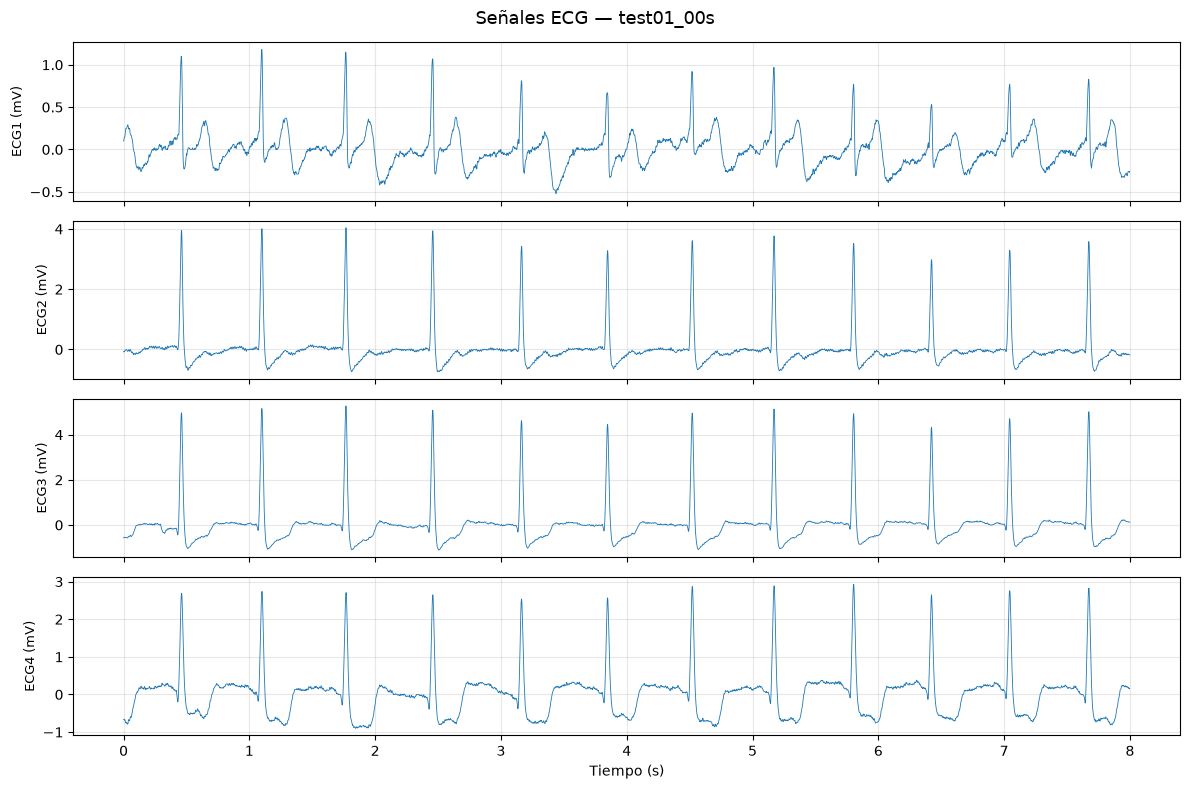

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Señales ECG — {records[0]}", fontsize=13)

for ax, ch in zip(axes, CHANNELS):
    ax.plot(df["time_s"], df[ch], linewidth=0.6)
    ax.set_ylabel(f"{ch} (mV)", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

## 5. Comparación entre actividades (un canal)

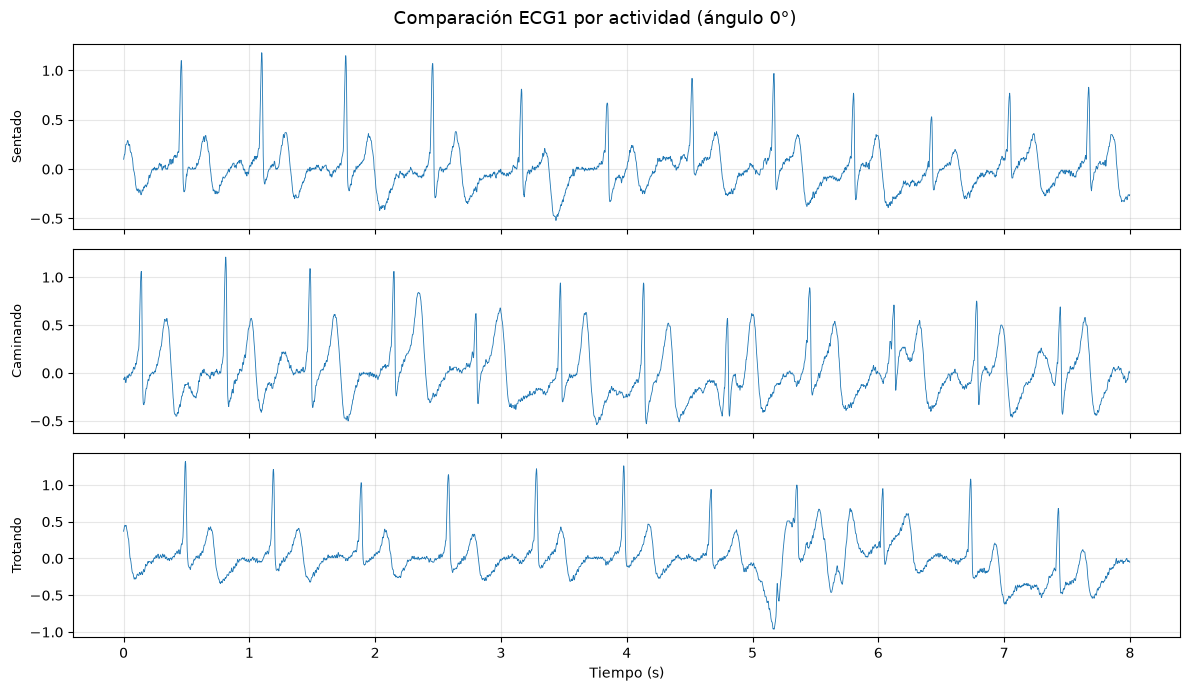

In [7]:
# Seleccionar un registro por actividad
ejemplos = {
    "Sentado":    "test01_00s",
    "Caminando":  "test10_00w",
    "Trotando":   "test19_00j",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Comparación ECG1 por actividad (ángulo 0°)", fontsize=13)

for ax, (label, rec_name) in zip(axes, ejemplos.items()):
    r = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    t = np.arange(r.sig_len) / r.fs
    ax.plot(t, r.p_signal[:, 0], linewidth=0.6)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

## 6. Tabla resumen de todos los registros

In [8]:
activity_map = {"s": "sentado", "w": "caminando", "j": "trotando"}
rows = []

for rec_name in records:
    parts = rec_name.replace("test", "")
    subject_id = int(parts[:2])
    angle = int(parts[3:5])
    activity = activity_map.get(parts[5], "?")
    r = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    sig = r.p_signal
    rows.append({
        "registro": rec_name,
        "sujeto": subject_id,
        "ángulo": angle,
        "actividad": activity,
        "muestras": r.sig_len,
        "duración_s": r.sig_len / r.fs,
        "media_ECG1": round(sig[:, 0].mean(), 4),
        "std_ECG1":  round(sig[:, 0].std(), 4),
    })

summary_df = pd.DataFrame(rows)
summary_df

,registro,sujeto,ángulo,actividad,muestras,duración_s,media_ECG1,std_ECG1
0,test01_00s,1,0,sentado,4000,8.0,0.0003,0.2124
1,test02_45s,2,45,sentado,4000,8.0,0.0026,0.6984
2,test03_90s,3,90,sentado,4000,8.0,0.0001,0.9487
3,test04_00s,4,0,sentado,4000,8.0,-0.0001,0.2190
4,test05_45s,5,45,sentado,4000,8.0,0.0020,0.3526
5,test06_90s,6,90,sentado,4000,8.0,0.0002,0.4615
6,test07_00s,7,0,sentado,4000,8.0,0.0004,0.1552
7,test08_45s,8,45,sentado,4000,8.0,0.0017,0.4362
8,test09_90s,9,90,sentado,4000,8.0,0.0010,0.3378
9,test10_00w,10,0,caminando,4000,8.0,0.0007,0.2825
